In [31]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns

results_dir = '/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results_sub'

data = []
for f in Path(results_dir).rglob('metrics.json'):
    with open(f) as file:
        data.append(json.load(file))

summary = pd.concat([pd.DataFrame(f) for f in data]).set_index(['benchmark_name','model']).sort_index()

In [32]:
summary.columns.name = 'metric'

tall = summary.stack()
tall.name = 'value'

tall = tall.to_frame().reset_index()

In [33]:
tall

,benchmark_name,model,metric,value
0,medexpqa,Qwen2.5-7B-Instruct,accuracy,0.650000
1,medexpqa,Qwen2.5-7B-Instruct,balanced_accuracy,0.610481
2,medexpqa,Qwen2.5-7B-Instruct,precision_macro,0.640130
3,medexpqa,Qwen2.5-7B-Instruct,recall_macro,0.610481
4,medexpqa,Qwen2.5-7B-Instruct,f1_macro,0.616162
...,...,...,...,...
265,medqa_test,Qwen3-4B,f1_macro,0.684021
266,medqa_test,Qwen3-4B,precision_weighted,0.690774
267,medqa_test,Qwen3-4B,recall_weighted,0.687000
268,medqa_test,Qwen3-4B,f1_weighted,0.688545


In [34]:
sns.set_style('whitegrid')

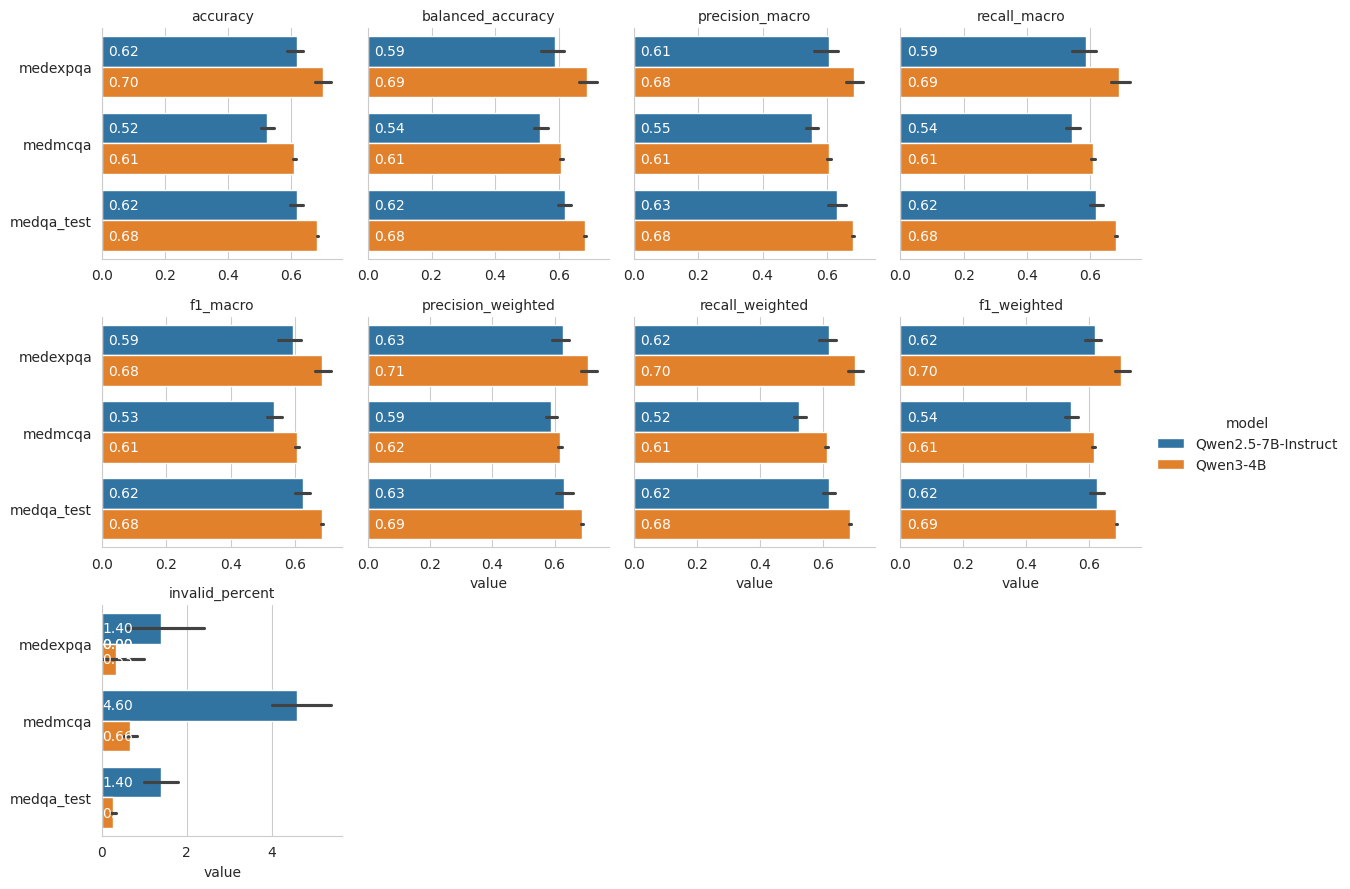

In [35]:
g = sns.catplot(
    tall,
    y="benchmark_name",
    x="value",
    col="metric",
    hue="model",
    sharex=False,
    col_wrap=4,
    height=3,
    kind='bar'
)

g.set_titles(col_template="{col_name}")

g.set_ylabels('')

for ax in g.axes:
    for p in ax.patches:
        ax.text(
            p.get_x() + 0.02,                       # left edge of the bar
            p.get_y() + p.get_height() / 2., # vertical center of the bar
            f"{p.get_width():.2f}",          # width is the bar value
            ha="left", va="center",color='white'
        )

# g.set(xlim=(0,1))

notice that we can read the configuration (e.g. temperature) from `config.yml` for each of these, so we know if it makes sense to average